# SABER Aggregate Model-Level Analysis (Cross-Domain)

## Purpose

This notebook aggregates **domain-agnostic** model comparison analysis across **all SABER benchmark domains**. It normalizes scores and metrics so that domains with many samples (e.g., Excytin with 599) don't dominate domains with few samples (e.g., CTI Realm with 25 or CyBench with 1).

### Normalization Method

For each metric (score, cost, tokens, tool calls, etc.):
1. Compute the **per-domain mean** for each model
2. Average these per-domain means with **equal weight per domain**

$$\text{Aggregate Score}(m) = \frac{1}{|\mathcal{D}|} \sum_{d \in \mathcal{D}} \overline{\text{score}}(m, d)$$

This ensures each domain contributes equally to the aggregate, regardless of sample count.

### Analyses

| # | Analysis | What it shows |
|---|----------|---------------|
| 1 | Normalized Overall Reward | Domain-weighted mean saber_overall per model |
| 2 | Per-Domain Score Breakdown | Model scores across all domains (heatmap + grouped bar) |
| 3 | Normalized Cost Analysis | Per-sample cost averaged across domains; Pareto chart |
| 4 | Normalized Cost Efficiency | Reward per dollar, domain-weighted |
| 5 | Sub-Task Breakdown | Submission/Checkpoints/Aggregate, domain-averaged |
| 6 | Agent Trajectory Efficiency | Tool calls, steps, and time per sample (domain-averaged) |
| 7 | Cross-Domain Ranking Consistency | Do models rank the same across domains? |
| 8 | Cross-Domain Radar Chart | Spider chart showing per-domain strength per model |

### Configuring Domains

Edit the `DOMAINS` dict in the Configuration cell to add/remove/modify domains.
Each domain entry specifies its eval logs, sample count, and file locations.

<a id="configuration"></a>
## Configuration

Edit the cell below to configure which **domains** and **models** are included in the aggregate analysis.

### Adding or removing domains

- Add a new key to `DOMAINS` with its eval logs and metadata
- Remove a domain by commenting out or deleting its entry
- Each domain's weight is equal: 1/|DOMAINS|

### Adding models

1. Add the model to each domain's `eval_logs` dict (and optionally `no_thinking_logs`)
2. Add a color in `COLORS`
3. Add pricing in `PRICING`

### Models with partial domain coverage

If a model doesn't appear in all domains, its aggregate is computed over only the domains where it has data. The number of contributing domains is shown in annotations.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Aggregate Model-Level Analysis (Cross-Domain)
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_baseline_logs, ensure_eval_files, load_trajectory_data
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts' / 'aggregate_model'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# DOMAIN REGISTRY — Add/remove domains here
# Each domain specifies: name, slug, n_samples, eval_logs, no_thinking_logs
# ══════════════════════════════════════════════════════════════════════════════
DOMAINS = {
    'excytin': {
        'name': 'Excytin',
        'n_samples': 599,
        'eval_logs': {
            'Claude Haiku 4.5':  'haiku_4.5_latest_test_set.eval',
            'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set.eval',
            'Claude Opus 4.6':   'opus_4.6_latest_test_set.eval',
            'GPT-5.4':           'gpt_5.4_latest_test_set.eval',
            'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set.eval',
        },
        'no_thinking_logs': {
            'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set_no_thinking.eval',
            'Claude Opus 4.6':   'opus_4.6_latest_test_set_no_thinking.eval',
            'GPT-5.4':           'gpt_5.4_latest_test_set_no_reasoning.eval',
            'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set_no_reasoning.eval',
        },
        'group_fn': lambda sid: '_'.join(sid.split('_')[:2]),
    },
    'cti_realm': {
        'name': 'CTI Realm',
        'n_samples': 25,
        'eval_logs': {
            'Claude Haiku 4.5':  'haiku_4.5_cti_realm_25.eval',
            'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25.eval',
            'Claude Opus 4.6':   'opus_4.6_cti_realm_25.eval',
            'GPT-5.4':           'gpt_5.4_cti_realm_25.eval',
            'GPT-5.4-mini':      'gpt_5.4_mini_cti_realm_25.eval',
        },
        'no_thinking_logs': {
            'Claude Sonnet 4.6': 'sonnet_4.6_cti_realm_25_no_thinking.eval',
            'Claude Opus 4.6':   'opus_4.6_cti_realm_25_no_thinking.eval',
            'GPT-5.4':           'gpt_5.4_cti_realm_25_no_reasoning.eval',
            'GPT-5.4-mini':      'gpt_5.4_mini_cti_realm_25_no_reasoning.eval',
        },
        'group_fn': lambda sid: sid.split('_')[0],
    },
    'cybench': {
        'name': 'CyBench',
        'n_samples': 1,
        'eval_logs': {
            'Claude Haiku 4.5':  'haiku_4.5_latest_test_set.eval',
            'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set.eval',
            'Claude Opus 4.6':   'opus_4.6_latest_test_set.eval',
            'GPT-5.4':           'gpt_5.4_latest_test_set.eval',
        },
        'no_thinking_logs': {
            'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set_no_thinking.eval',
            'Claude Opus 4.6':   'opus_4.6_latest_test_set_no_thinking.eval',
            'GPT-5.4':           'gpt_5.4_latest_test_set_no_reasoning.eval',
        },
        'group_fn': lambda sid: '_'.join(sid.split('_')[:-2]),
    },
}

# ══════════════════════════════════════════════════════════════════════════════
# MODEL DISPLAY — colors and ordering
# ══════════════════════════════════════════════════════════════════════════════
COLORS = {
    'Claude Haiku 4.5':  '#17BECF',
    'Claude Sonnet 4.6': '#F39C12',
    'Claude Opus 4.6':   '#E74C3C',
    'GPT-5.4':           '#2CA02C',
    'GPT-5.4-mini':      '#7B4FBF',
}

# Discover all models across all domains (ordered by first appearance)
_seen = set()
MODEL_ORDER = []
for d_cfg in DOMAINS.values():
    for m in d_cfg['eval_logs']:
        if m not in _seen:
            MODEL_ORDER.append(m)
            _seen.add(m)

# ══════════════════════════════════════════════════════════════════════════════
# PRICING — $/1M tokens
# ══════════════════════════════════════════════════════════════════════════════
PRICING = {
    'anthropic/claude-haiku-4-5':            {'input': 0.80,  'output': 4.00,  'cache_read': 0.08,   'cache_write': 1.00},
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
    'anthropic/claude-opus-4-6':             {'input': 15.00, 'output': 75.00, 'cache_read': 1.875,  'cache_write': 18.75},
    'openai/azure/gpt-5.4':                  {'input': 10.00, 'output': 30.00, 'cache_read': 2.50,   'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini':             {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini-2026-03-17':  {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
}

# Domain display colors (for per-domain charts)
DOMAIN_COLORS = {
    'excytin':   '#3498DB',
    'cti_realm': '#E74C3C',
    'cybench':   '#2ECC71',
}

print(f'Aggregate Analysis Configuration')
print(f'  Domains: {len(DOMAINS)} — {", ".join(d["name"] for d in DOMAINS.values())}')
print(f'  Models:  {len(MODEL_ORDER)} — {", ".join(MODEL_ORDER)}')
for slug, d_cfg in DOMAINS.items():
    coverage = [m for m in MODEL_ORDER if m in d_cfg['eval_logs']]
    print(f'  {d_cfg["name"]:12s}: {d_cfg["n_samples"]:>4d} samples, {len(coverage)}/{len(MODEL_ORDER)} models')

Aggregate Analysis Configuration
  Domains: 3 — Excytin, CTI Realm, CyBench
  Models:  5 — Claude Haiku 4.5, Claude Sonnet 4.6, Claude Opus 4.6, GPT-5.4, GPT-5.4-mini
  Excytin     :  599 samples, 5/5 models
  CTI Realm   :   25 samples, 5/5 models
  CyBench     :    1 samples, 4/5 models


## Data Loading

### What this does

For each domain, loads eval logs and extracts:
- **Per-domain overall scores** — `saber_overall` mean/stderr per model
- **Per-domain sample scores** — individual sample scores for distribution analysis
- **Per-domain sub-task scores** — submission, checkpoints, aggregate
- **Per-domain baselines** — no-reasoning runs for delta comparison
- **Per-domain cost/token data** — from eval log headers
- **Per-domain trajectory data** — tool calls, steps, timing

All per-domain means are then assembled into a **cross-domain DataFrame** for normalized aggregate computation.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING — Load all domains and build cross-domain DataFrames
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

domain_data = {}  # slug -> {samples_df, subtasks_df, overall_df, model_overall, ...}

for slug, d_cfg in DOMAINS.items():
    log_dir = str(REPO_ROOT / 'eval_samples' / slug)
    d_model_order = [m for m in MODEL_ORDER if m in d_cfg['eval_logs']]

    # Ensure files are available
    ensure_eval_files(
        d_cfg['eval_logs'], log_dir, slug,
        baseline_logs=d_cfg.get('no_thinking_logs'),
        fallback_dirs=[str(REPO_ROOT / 'latest_experiments' / slug)],
    )

    # Load main eval data
    samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
        d_cfg['eval_logs'], log_dir, d_model_order, group_fn=d_cfg.get('group_fn')
    )

    # Load baselines
    no_thinking_logs = d_cfg.get('no_thinking_logs', {})
    baseline_samples_df, baseline_subtasks_df, no_thinking_overall = load_baseline_logs(
        no_thinking_logs, log_dir, group_fn=d_cfg.get('group_fn')
    )

    # Load cost data
    cost_rows = extract_cost_rows(d_cfg['eval_logs'], log_dir, PRICING, d_cfg['n_samples'])
    cost_df = pd.DataFrame(cost_rows).set_index('model').reindex(d_model_order)

    baseline_cost_rows = extract_cost_rows(no_thinking_logs, log_dir, PRICING, d_cfg['n_samples'])
    baseline_cost_df = pd.DataFrame(baseline_cost_rows).set_index('model') if baseline_cost_rows else pd.DataFrame()

    # Load trajectory data
    traj_df = load_trajectory_data(d_cfg['eval_logs'], log_dir, d_model_order, group_fn=d_cfg.get('group_fn'))
    traj_df['tool_counts'] = traj_df['tool_counts'].apply(
        lambda d: dict(Counter({k.lower(): v for k, v in d.items()}))
    )

    domain_data[slug] = {
        'samples_df': samples_df,
        'subtasks_df': subtasks_df,
        'overall_df': overall_df,
        'model_overall': model_overall,
        'baseline_samples_df': baseline_samples_df,
        'baseline_subtasks_df': baseline_subtasks_df,
        'no_thinking_overall': no_thinking_overall,
        'cost_df': cost_df,
        'baseline_cost_df': baseline_cost_df,
        'traj_df': traj_df,
        'model_order': d_model_order,
    }
    print(f'  {d_cfg["name"]:12s}: {len(samples_df)} samples, {len(subtasks_df)} subtasks, {len(traj_df)} trajectories')

# ══════════════════════════════════════════════════════════════════════════════
# BUILD CROSS-DOMAIN AGGREGATE TABLES
# ══════════════════════════════════════════════════════════════════════════════
domain_slugs = list(DOMAINS.keys())
domain_names = {s: DOMAINS[s]['name'] for s in domain_slugs}

# Per-domain mean score per model → DataFrame (models × domains)
score_by_domain = pd.DataFrame(index=MODEL_ORDER, columns=domain_slugs, dtype=float)
for slug, dd in domain_data.items():
    for m, stats in dd['model_overall'].items():
        score_by_domain.loc[m, slug] = stats['mean']

# Aggregate score: equal-weight mean across domains (ignoring NaN for partial coverage)
agg_scores = score_by_domain.mean(axis=1)
agg_stderr = score_by_domain.sem(axis=1)  # SE across domains (measures cross-domain variance)
domain_coverage = score_by_domain.notna().sum(axis=1)  # how many domains each model covers

print(f'\n═══ Per-Domain Mean Scores ═══')
display_scores = score_by_domain.copy()
display_scores.columns = [domain_names[s] for s in domain_slugs]
display_scores['Aggregate'] = agg_scores
display_scores['Domains'] = domain_coverage
print(display_scores.round(4).to_string())

# Per-domain cost per sample → DataFrame
cost_per_sample_by_domain = pd.DataFrame(index=MODEL_ORDER, columns=domain_slugs, dtype=float)
for slug, dd in domain_data.items():
    for m in dd['cost_df'].index:
        if m in cost_per_sample_by_domain.index:
            cost_per_sample_by_domain.loc[m, slug] = dd['cost_df'].loc[m, 'cost_per_sample']

agg_cost_per_sample = cost_per_sample_by_domain.mean(axis=1)

# Per-domain per-sample trajectory stats
traj_by_domain = {}
for metric in ['n_tool_calls', 'n_steps', 'total_time']:
    tdf = pd.DataFrame(index=MODEL_ORDER, columns=domain_slugs, dtype=float)
    for slug, dd in domain_data.items():
        for m in dd['model_order']:
            mdf = dd['traj_df'][dd['traj_df']['model'] == m]
            if len(mdf) > 0:
                tdf.loc[m, slug] = mdf[metric].mean()
    traj_by_domain[metric] = tdf

agg_tool_calls = traj_by_domain['n_tool_calls'].mean(axis=1)
agg_steps = traj_by_domain['n_steps'].mean(axis=1)
agg_time = traj_by_domain['total_time'].mean(axis=1)

print(f'\n═══ Aggregate Scores (domain-normalized) ═══')
for m in MODEL_ORDER:
    cov = int(domain_coverage[m])
    print(f'  {m:25s}  agg={agg_scores[m]:.4f}  (across {cov} domains)')

✓ All 9 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/excytin
  Excytin     : 2995 samples, 12985 subtasks, 2995 trajectories
✓ All 9 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/cti_realm
  CTI Realm   : 125 samples, 750 subtasks, 125 trajectories
✓ All 7 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/cybench
  CyBench     : 4 samples, 32 subtasks, 4 trajectories

═══ Per-Domain Mean Scores ═══
                   Excytin  CTI Realm  CyBench  Aggregate  Domains
Claude Haiku 4.5    0.8381     0.4939      1.0     0.7773        3
Claude Sonnet 4.6   0.8567     0.5467      1.0     0.8011        3
Claude Opus 4.6     0.8649     0.6263      1.0     0.8304        3
GPT-5.4             0.8752     0.6199      1.0     0.8317        3
GPT-5.4-mini        0.8265     0.6167      NaN     0.7216        2

═══ Aggregate Scores (domain-normalized) ═══
  Claude Haiku 4.5           agg=0.7773  (across 3 domains)
  Clau

---

## 1. Normalized Overall Reward Distribution

### What this measures

The **domain-normalized aggregate score** for each model. Each domain contributes equally regardless of sample count.

### How to read the chart

- **Solid bars** = aggregate score across all domains
- **Error bars** = standard error across domain means (measures cross-domain consistency)
- **Domain count annotation** shows how many domains contribute to each model's aggregate
- Higher is better (max = 1.0)

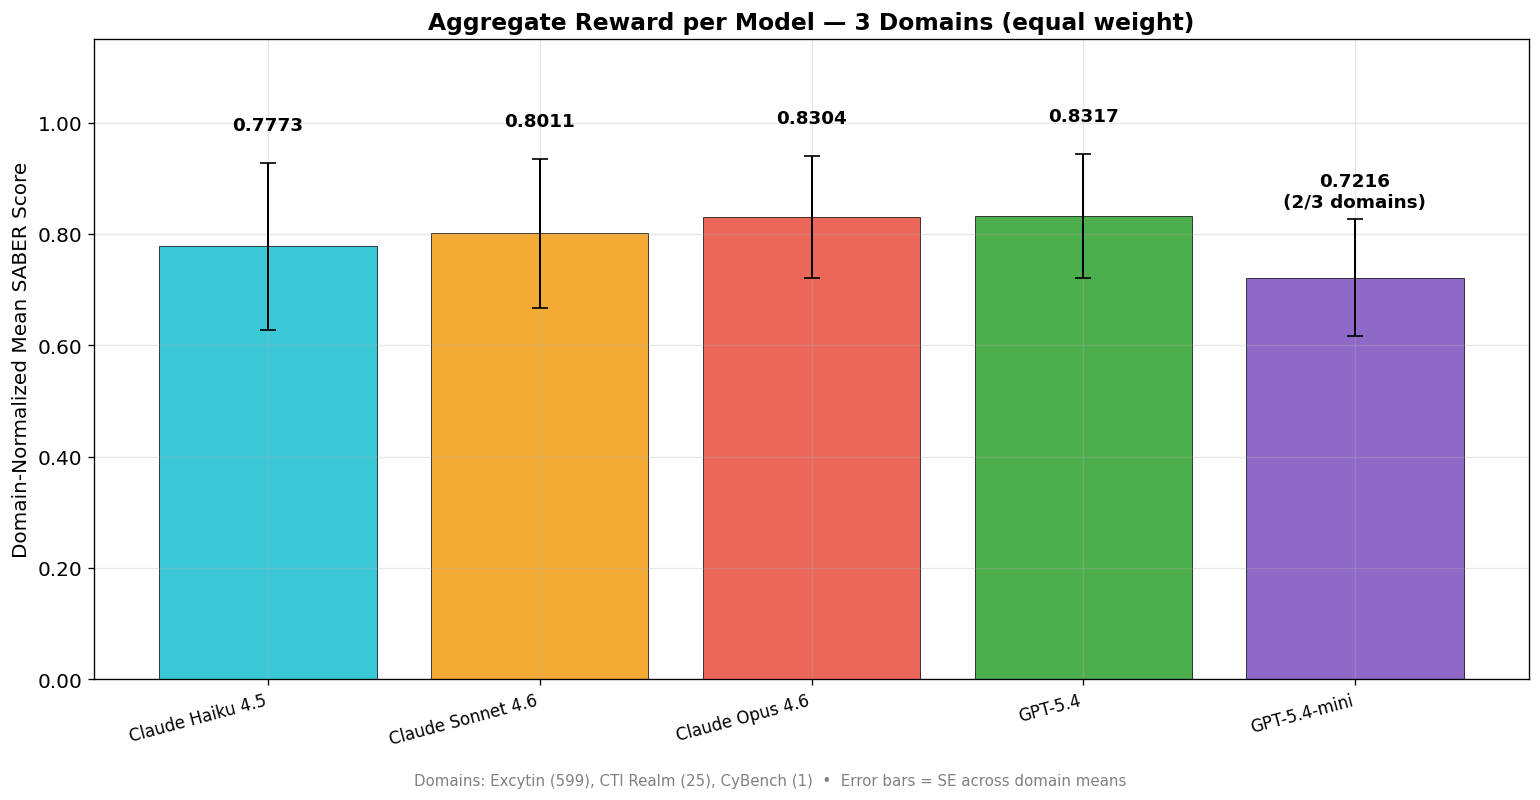

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Normalized Overall Reward Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6.5))

x = np.arange(len(MODEL_ORDER))
colors = [COLORS.get(m, '#888888') for m in MODEL_ORDER]
means = [agg_scores[m] for m in MODEL_ORDER]
stderrs = [agg_stderr[m] if not np.isnan(agg_stderr[m]) else 0 for m in MODEL_ORDER]

bars = ax.bar(x, means, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)

for i, m in enumerate(MODEL_ORDER):
    cov = int(domain_coverage[m])
    n_domains = len(DOMAINS)
    cov_label = f'({cov}/{n_domains} domains)' if cov < n_domains else ''
    ax.text(i, means[i] + stderrs[i] + 0.015, f'{means[i]:.4f}\n{cov_label}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Domain-Normalized Mean SABER Score')
ax.set_title(f'Aggregate Reward per Model — {len(DOMAINS)} Domains (equal weight)',
             fontweight='bold')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Domain count footnote
domain_desc = ', '.join(f'{DOMAINS[s]["name"]} ({DOMAINS[s]["n_samples"]})'
                        for s in domain_slugs)
fig.text(0.5, -0.02, f'Domains: {domain_desc}  •  Error bars = SE across domain means',
         ha='center', fontsize=9, fontstyle='italic', color='gray')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_overall_reward.png', bbox_inches='tight')
plt.show()

---

## 2. Per-Domain Score Breakdown

### What this measures

Shows each model's performance **per domain** — reveals strengths and weaknesses across different cybersecurity task types.

### Charts

1. **Grouped bar chart** — domains side by side for each model
2. **Heatmap** — models × domains with color-coded scores

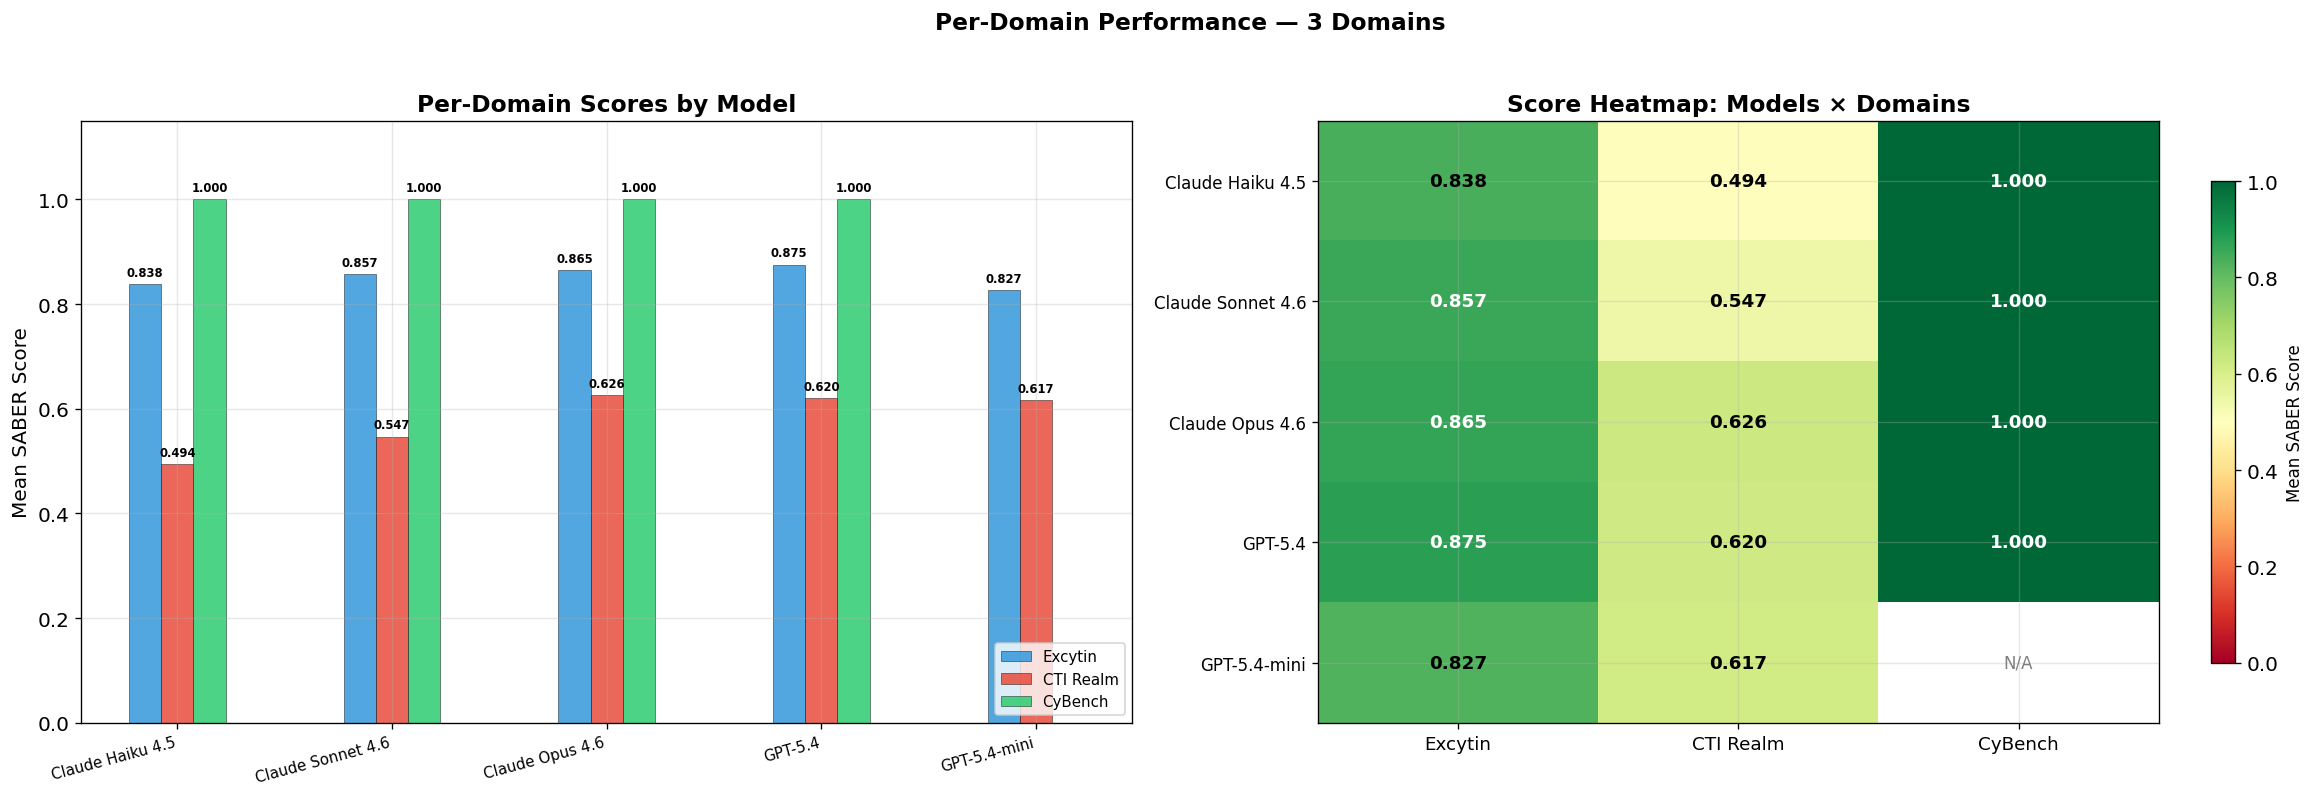

═══ Model Rankings per Domain ═══
  Excytin     : GPT-5.4 (0.875), Claude Opus 4.6 (0.865), Claude Sonnet 4.6 (0.857), Claude Haiku 4.5 (0.838), GPT-5.4-mini (0.827)
  CTI Realm   : Claude Opus 4.6 (0.626), GPT-5.4 (0.620), GPT-5.4-mini (0.617), Claude Sonnet 4.6 (0.547), Claude Haiku 4.5 (0.494)
  CyBench     : Claude Haiku 4.5 (1.000), Claude Sonnet 4.6 (1.000), Claude Opus 4.6 (1.000), GPT-5.4 (1.000)


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-Domain Score Breakdown
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(20, 6.5))

# Panel 1: Grouped bar chart — for each model, show score per domain
ax = axes[0]
n_domains = len(domain_slugs)
bar_width = 0.15
x = np.arange(len(MODEL_ORDER))

for j, slug in enumerate(domain_slugs):
    offset = (j - n_domains/2 + 0.5) * bar_width
    vals = [score_by_domain.loc[m, slug] if not pd.isna(score_by_domain.loc[m, slug]) else 0
            for m in MODEL_ORDER]
    ax.bar(x + offset, vals, bar_width, color=DOMAIN_COLORS.get(slug, '#888'),
           edgecolor='black', linewidth=0.3, alpha=0.85,
           label=DOMAINS[slug]['name'])
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(x[i] + offset, v + 0.01, f'{v:.3f}', ha='center', va='bottom',
                    fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score')
ax.set_title('Per-Domain Scores by Model', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9, loc='lower right')

# Panel 2: Heatmap — models × domains
ax = axes[1]
heatmap_data = score_by_domain.copy()
heatmap_data.columns = [domain_names[s] for s in domain_slugs]
heatmap_arr = heatmap_data.values.astype(float)

im = ax.imshow(heatmap_arr, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
for i in range(len(MODEL_ORDER)):
    for j in range(n_domains):
        val = heatmap_arr[i, j]
        if not np.isnan(val):
            text_color = 'white' if val < 0.3 or val > 0.85 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)
        else:
            ax.text(j, i, 'N/A', ha='center', va='center',
                    fontsize=10, color='gray', fontstyle='italic')

ax.set_xticks(range(n_domains))
ax.set_xticklabels(heatmap_data.columns, fontsize=11)
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_title('Score Heatmap: Models × Domains', fontweight='bold')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Mean SABER Score', fontsize=10)

fig.suptitle(f'Per-Domain Performance — {len(DOMAINS)} Domains', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'per_domain_breakdown.png', bbox_inches='tight')
plt.show()

# Summary: model rankings per domain
print('═══ Model Rankings per Domain ═══')
for slug in domain_slugs:
    col = score_by_domain[slug].dropna().sort_values(ascending=False)
    ranked = ', '.join(f'{m} ({v:.3f})' for m, v in col.items())
    print(f'  {domain_names[slug]:12s}: {ranked}')

---

## 3. Normalized Cost Analysis

### What this measures

**Per-sample cost** averaged across domains with equal weight. This normalizes for different sample counts and shows the true cost of running a model on a "typical" SABER task.

### Charts

1. **Per-sample cost** — domain-averaged cost of one task evaluation
2. **Pareto: Score vs. Cost** — upper-left = best value

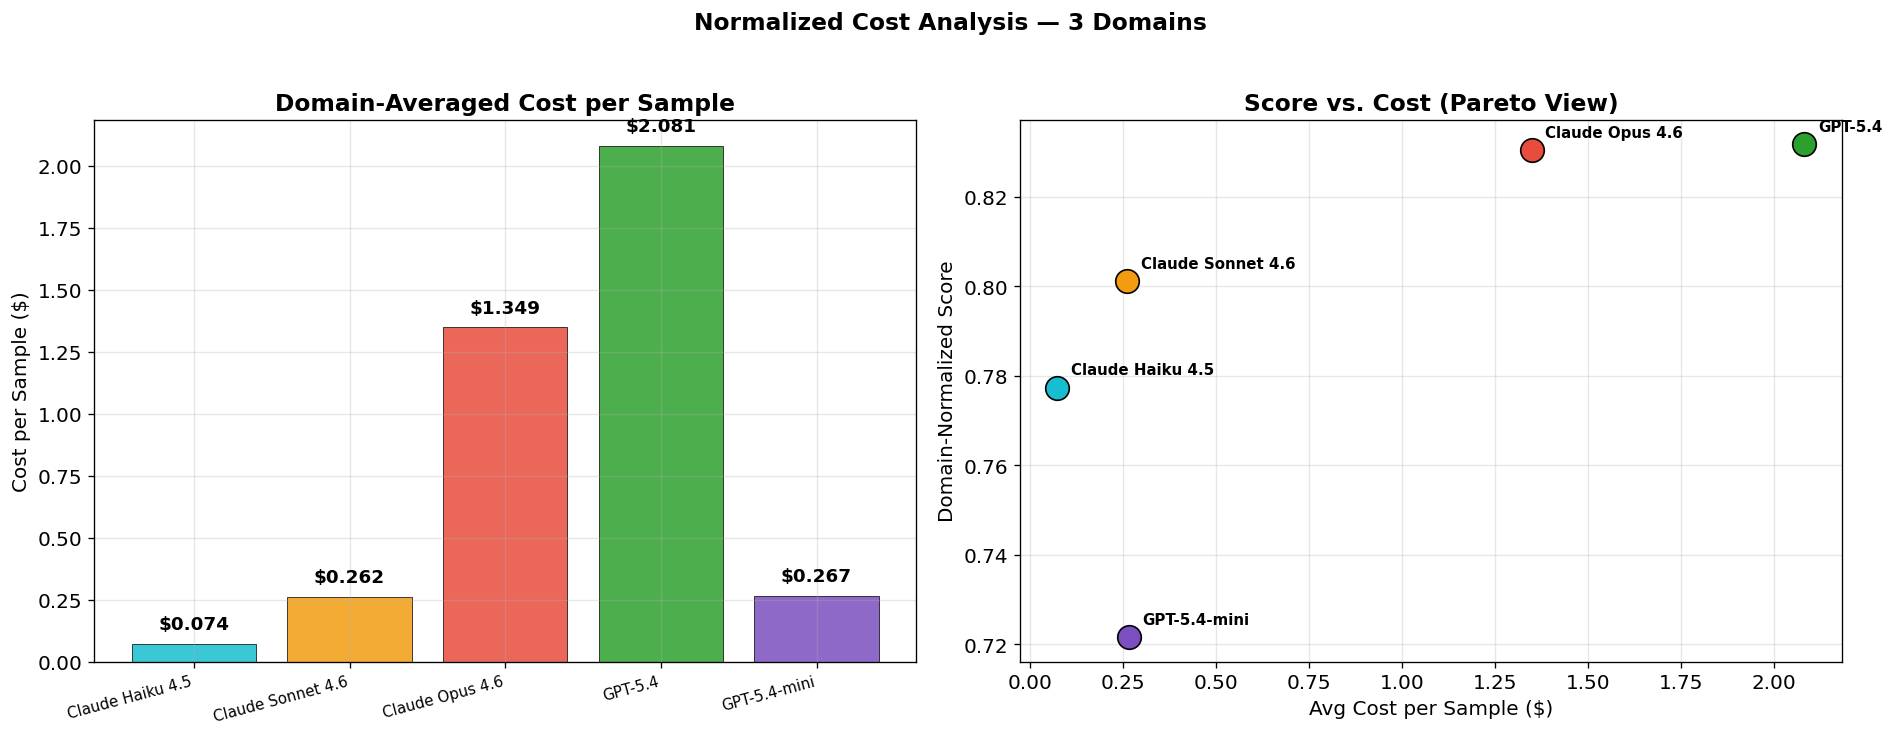

═══ Per-Domain Cost per Sample ═══
                   Excytin  CTI Realm  CyBench  Aggregate
Claude Haiku 4.5    0.0584     0.0970   0.0668     0.0741
Claude Sonnet 4.6   0.2011     0.3598   0.2265     0.2625
Claude Opus 4.6     0.7375     2.0341   1.2739     1.3485
GPT-5.4             1.1215     4.9443   0.1781     2.0813
GPT-5.4-mini        0.1966     0.3365      NaN     0.2666


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: Normalized Cost Analysis
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(MODEL_ORDER))
colors = [COLORS.get(m, '#888888') for m in MODEL_ORDER]

# Panel 1: Domain-averaged cost per sample
ax = axes[0]
cps_vals = [agg_cost_per_sample[m] if not np.isnan(agg_cost_per_sample[m]) else 0 for m in MODEL_ORDER]
ax.bar(x, cps_vals, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
for i, v in enumerate(cps_vals):
    ax.text(i, v + max(cps_vals)*0.02, f'${v:.3f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Cost per Sample ($)')
ax.set_title('Domain-Averaged Cost per Sample', fontweight='bold')

# Panel 2: Pareto — aggregate score vs. aggregate cost per sample
ax = axes[1]
for m in MODEL_ORDER:
    s = agg_scores[m]
    c = agg_cost_per_sample[m]
    if np.isnan(s) or np.isnan(c):
        continue
    ax.scatter(c, s, s=200, color=COLORS.get(m, '#888'), edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(m, (c, s), textcoords='offset points', xytext=(8, 8),
                fontsize=9, fontweight='bold')
ax.set_xlabel('Avg Cost per Sample ($)')
ax.set_ylabel('Domain-Normalized Score')
ax.set_title('Score vs. Cost (Pareto View)', fontweight='bold')

fig.suptitle(f'Normalized Cost Analysis — {len(DOMAINS)} Domains',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_cost_analysis.png', bbox_inches='tight')
plt.show()

# Per-domain cost breakdown table
print('═══ Per-Domain Cost per Sample ═══')
cps_display = cost_per_sample_by_domain.copy()
cps_display.columns = [domain_names[s] for s in domain_slugs]
cps_display['Aggregate'] = agg_cost_per_sample
print(cps_display.round(4).to_string())

---

## 4. Normalized Cost Efficiency: Reward per Dollar

$$\text{Cost Efficiency} = \frac{\text{Domain-Normalized Score}}{\text{Domain-Averaged Cost per Sample}}$$

Higher = better value for money. Measures how much aggregate score you get per dollar of per-sample cost.

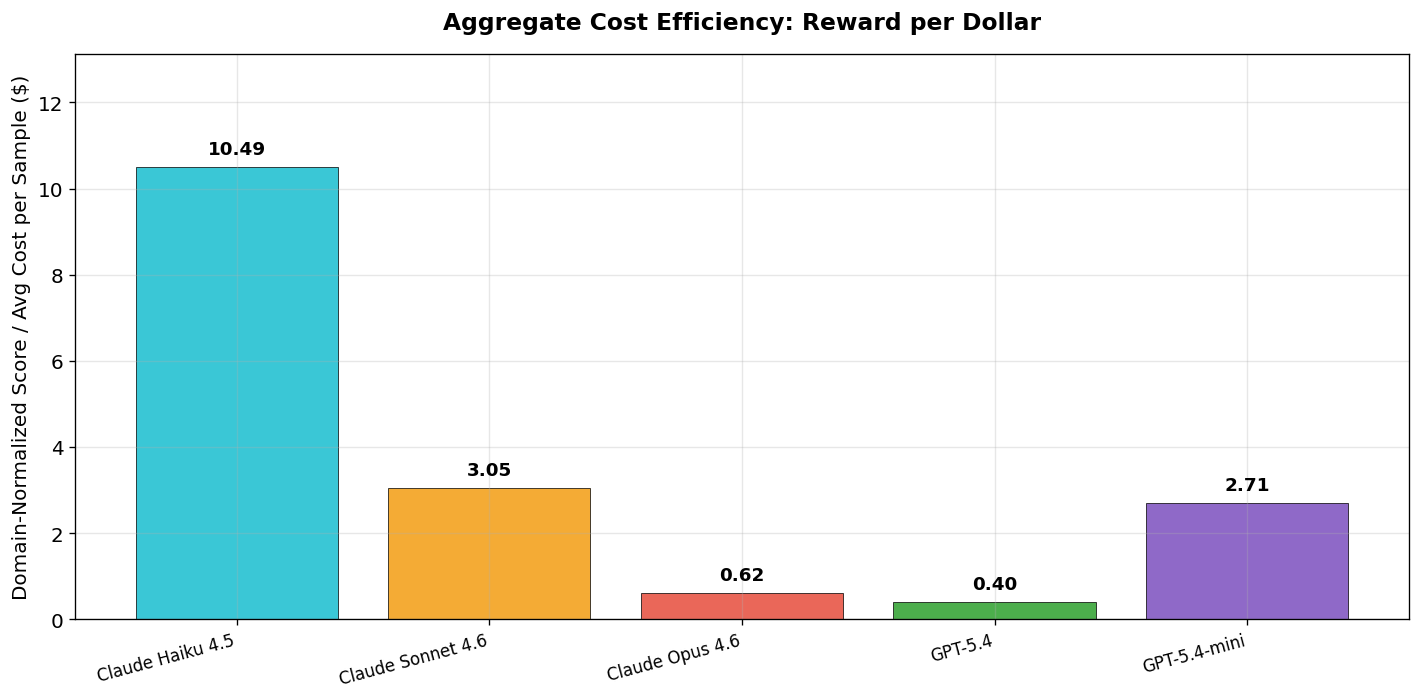

═══ Cost Efficiency Summary ═══
Model                      Agg Score Avg $/sample    Score/$  Domains
──────────────────────────────────────────────────────────────────────
Claude Haiku 4.5              0.7773 $     0.0741      10.49        3
Claude Sonnet 4.6             0.8011 $     0.2625       3.05        3
Claude Opus 4.6               0.8304 $     1.3485       0.62        3
GPT-5.4                       0.8317 $     2.0813       0.40        3
GPT-5.4-mini                  0.7216 $     0.2666       2.71        2


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Normalized Cost Efficiency — Reward per Dollar
# ══════════════════════════════════════════════════════════════════════════════
reward_per_dollar = agg_scores / agg_cost_per_sample

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(MODEL_ORDER))
rpd_vals = [reward_per_dollar[m] if not np.isnan(reward_per_dollar[m]) else 0 for m in MODEL_ORDER]

for i, m in enumerate(MODEL_ORDER):
    ax.bar(i, rpd_vals[i], color=COLORS.get(m, '#888'), edgecolor='black',
           linewidth=0.5, alpha=0.85)
    ax.text(i, rpd_vals[i] + max(v for v in rpd_vals if not np.isnan(v))*0.02,
            f'{rpd_vals[i]:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Domain-Normalized Score / Avg Cost per Sample ($)')
ax.set_title('Aggregate Cost Efficiency: Reward per Dollar', fontweight='bold', pad=15)
ax.set_ylim(0, max(v for v in rpd_vals if not np.isnan(v)) * 1.25)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_cost_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Cost Efficiency Summary ═══')
print(f'{"Model":25s} {"Agg Score":>10s} {"Avg $/sample":>12s} {"Score/$":>10s} {"Domains":>8s}')
print('─' * 70)
for m in MODEL_ORDER:
    cov = int(domain_coverage[m])
    print(f'{m:25s} {agg_scores[m]:10.4f} ${agg_cost_per_sample[m]:11.4f} '
          f'{reward_per_dollar[m]:10.2f} {cov:8d}')

---

## 5. Sub-Task Breakdown (Domain-Normalized)

### What this measures

For each score category (Submission, Checkpoints, Aggregate), computes the per-domain mean and then averages across domains with equal weight.

- **Submission** — final answer correctness
- **Checkpoints** — intermediate investigative steps
- **Aggregate** — weighted combination

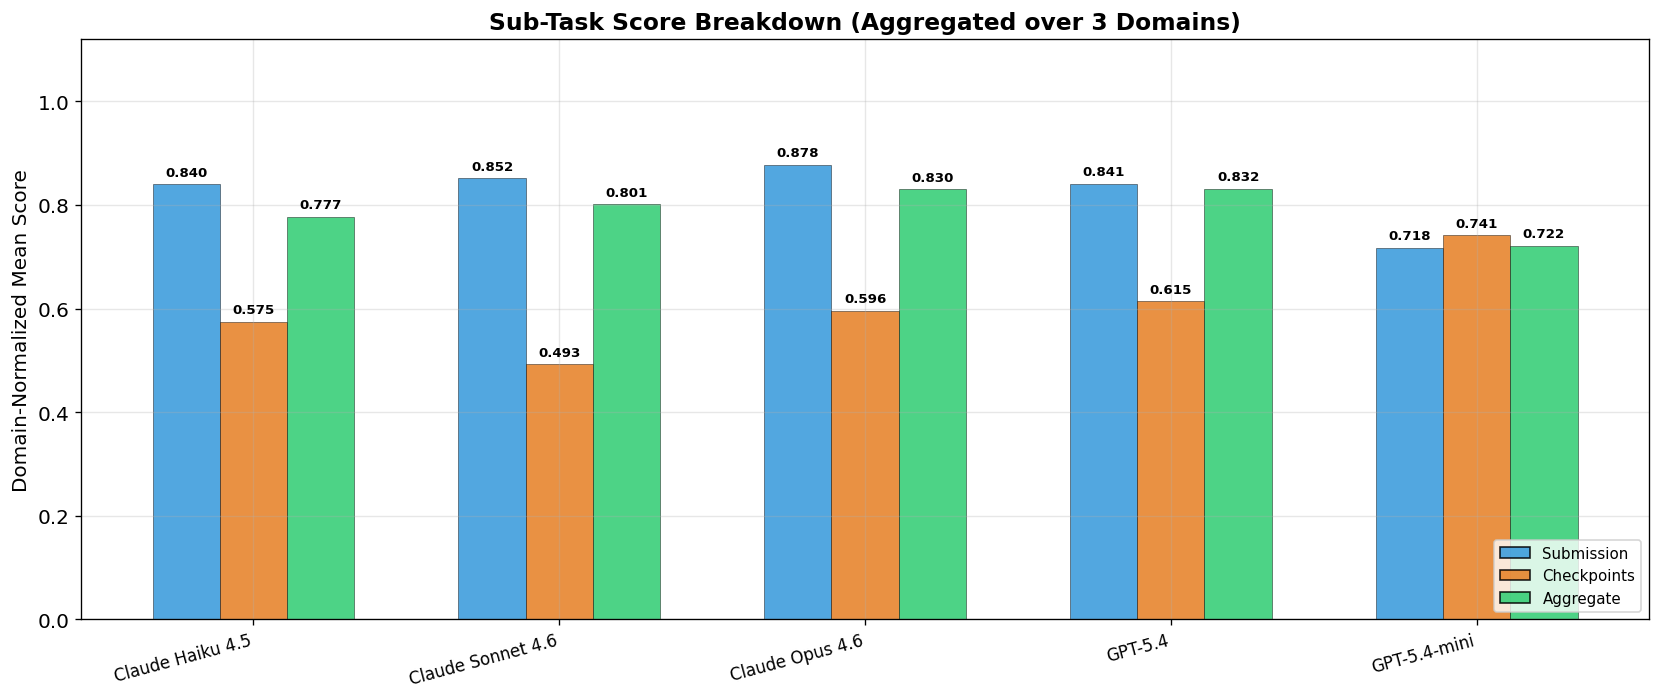


═══ Submission Scores per Domain ═══
                   Excytin  CTI Realm  CyBench  Aggregate
Claude Haiku 4.5    0.6795        NaN      1.0     0.8397
Claude Sonnet 4.6   0.7045        NaN      1.0     0.8523
Claude Opus 4.6     0.7563        NaN      1.0     0.8781
GPT-5.4             0.6828        NaN      1.0     0.8414
GPT-5.4-mini        0.7179        NaN      NaN     0.7179

═══ Checkpoints Scores per Domain ═══
                   Excytin  CTI Realm  CyBench  Aggregate
Claude Haiku 4.5    0.2374     0.9877   0.5000     0.5750
Claude Sonnet 4.6   0.2185     1.0934   0.1667     0.4928
Claude Opus 4.6     0.2028     1.2527   0.3333     0.5963
GPT-5.4             0.2709     1.2397   0.3333     0.6146
GPT-5.4-mini        0.2489     1.2334      NaN     0.7411

═══ Aggregate Scores per Domain ═══
                   Excytin  CTI Realm  CyBench  Aggregate
Claude Haiku 4.5    0.8381     0.4939      1.0     0.7773
Claude Sonnet 4.6   0.8567     0.5467      1.0     0.8011
Claude Opus 4.6 

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Sub-Task Breakdown (Domain-Normalized)
# ══════════════════════════════════════════════════════════════════════════════
categories_list = ['Submission', 'Checkpoints', 'Aggregate']

# Compute per-domain per-model category means, then aggregate
cat_by_domain = {}  # category -> DataFrame (models × domains)
for cat in categories_list:
    cdf = pd.DataFrame(index=MODEL_ORDER, columns=domain_slugs, dtype=float)
    for slug, dd in domain_data.items():
        st_df = dd['subtasks_df'].copy()
        st_df['category'] = st_df['score_type'].apply(classify_score_type)
        cat_data = st_df[st_df['category'] == cat]
        for m in dd['model_order']:
            vals = cat_data[cat_data['model'] == m]['score']
            if len(vals) > 0:
                cdf.loc[m, slug] = vals.mean()
    cat_by_domain[cat] = cdf

agg_cat = {cat: cdf.mean(axis=1) for cat, cdf in cat_by_domain.items()}

fig, ax = plt.subplots(figsize=(14, 6))
cat_plot_colors = ['#3498DB', '#E67E22', '#2ECC71']
x = np.arange(len(MODEL_ORDER))
bar_width = 0.22

for j, (cat, color) in enumerate(zip(categories_list, cat_plot_colors)):
    offset = (j - 1) * bar_width
    vals = [agg_cat[cat][m] if not np.isnan(agg_cat[cat][m]) else 0 for m in MODEL_ORDER]
    ax.bar(x + offset, vals, bar_width, color=color, edgecolor='black',
           linewidth=0.3, alpha=0.85)
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(x[i] + offset, v + 0.01, f'{v:.3f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

cat_handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.85, label=cat)
               for cat, c in zip(categories_list, cat_plot_colors)]
ax.legend(handles=cat_handles, fontsize=9, loc='lower right')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Domain-Normalized Mean Score')
ax.set_title(f'Sub-Task Score Breakdown (Aggregated over {len(DOMAINS)} Domains)', fontweight='bold')
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_subtask_breakdown.png', bbox_inches='tight')
plt.show()

# Table: per-domain, per-category
for cat in categories_list:
    print(f'\n═══ {cat} Scores per Domain ═══')
    tbl = cat_by_domain[cat].copy()
    tbl.columns = [domain_names[s] for s in domain_slugs]
    tbl['Aggregate'] = agg_cat[cat]
    print(tbl.round(4).to_string())

---

## 6. Agent Trajectory Efficiency (Domain-Normalized)

### What this measures

Per-sample effort metrics (tool calls, steps, time) averaged across domains. Reveals which models are most efficient regardless of domain.

### Charts

1. **Reward per tool call** — higher = more efficient use of tools
2. **Reward per minute** — higher = faster and more accurate
3. **Tool calls per sample** — lower (for same score) = more focused

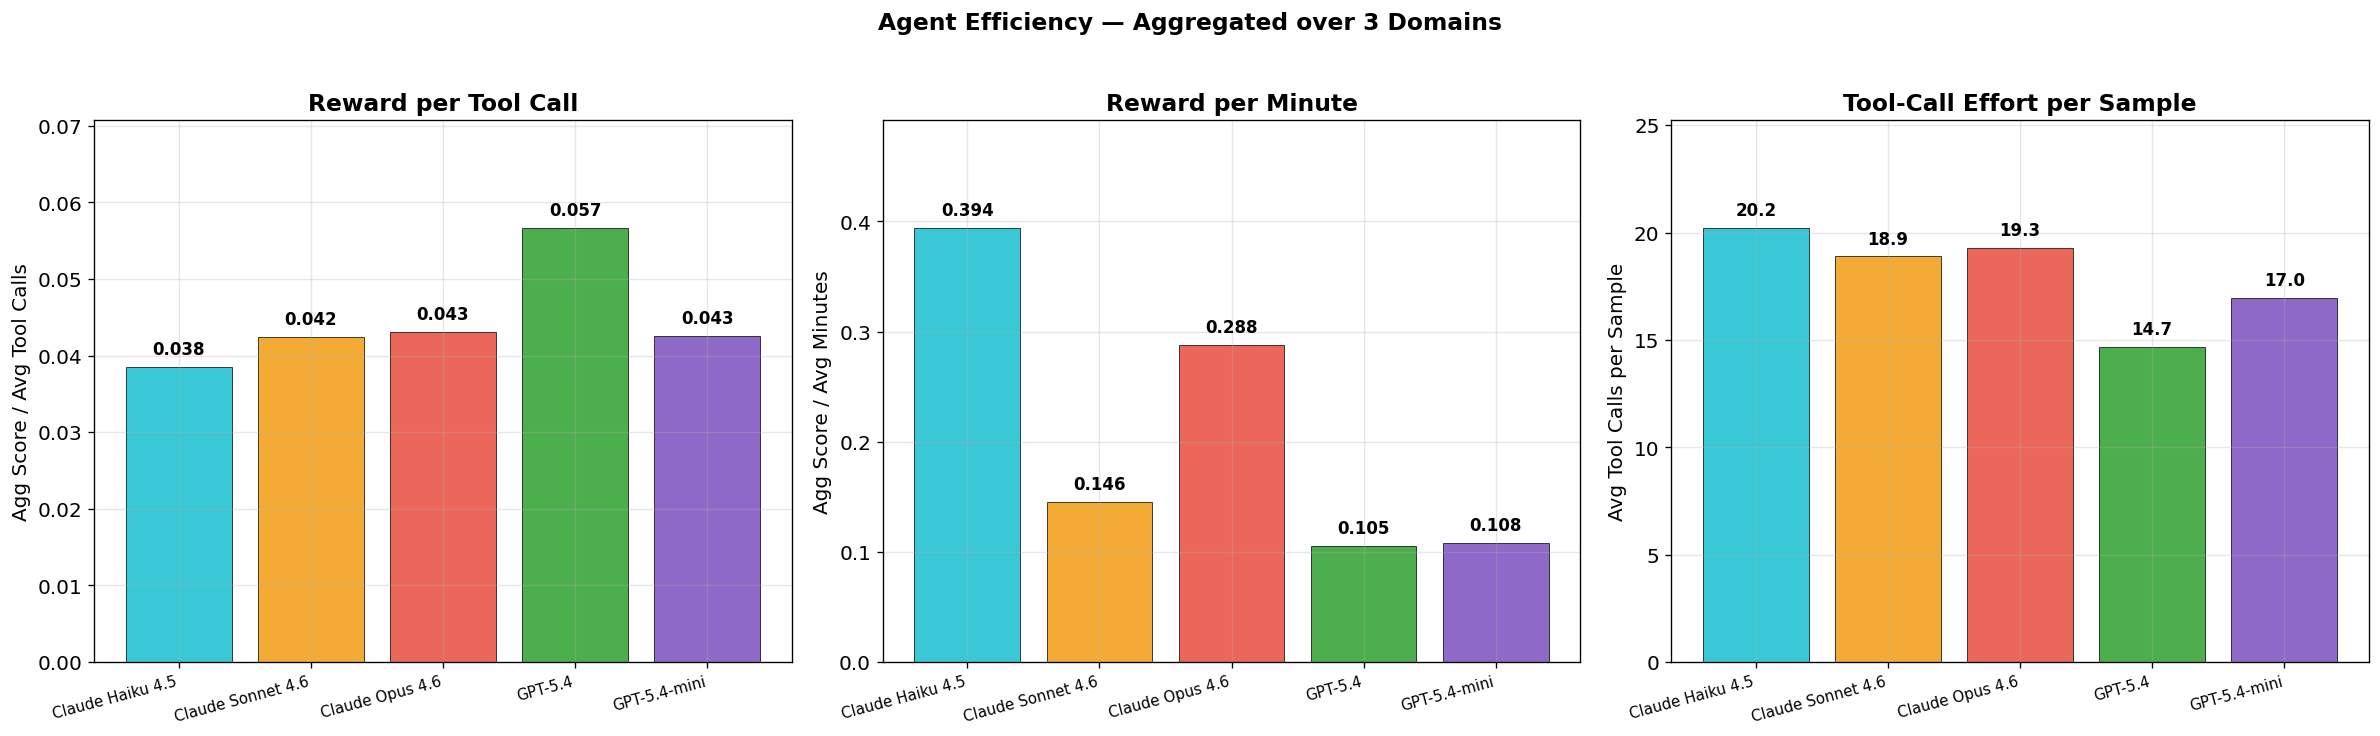

═══ Aggregate Efficiency Summary ═══
Model                      Agg Score  Avg Calls   Avg Time   Rew/Call    Rew/Min
────────────────────────────────────────────────────────────────────────────────
Claude Haiku 4.5              0.7773       20.2       2.0m     0.0385     0.3938
Claude Sonnet 4.6             0.8011       18.9       5.5m     0.0424     0.1456
Claude Opus 4.6               0.8304       19.3       2.9m     0.0431     0.2882
GPT-5.4                       0.8317       14.7       7.9m     0.0566     0.1051
GPT-5.4-mini                  0.7216       17.0       6.7m     0.0426     0.1084


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Agent Trajectory Efficiency (Domain-Normalized)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(MODEL_ORDER))

# Panel 1: Reward per tool call
ax = axes[0]
rpc_vals = [(agg_scores[m] / agg_tool_calls[m]) if agg_tool_calls[m] > 0 and not np.isnan(agg_tool_calls[m]) else 0
            for m in MODEL_ORDER]
for i, m in enumerate(MODEL_ORDER):
    ax.bar(i, rpc_vals[i], color=COLORS.get(m, '#888'), edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpc_vals[i] + max(v for v in rpc_vals if v > 0)*0.02, f'{rpc_vals[i]:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Agg Score / Avg Tool Calls')
ax.set_title('Reward per Tool Call', fontweight='bold')
ax.set_ylim(0, max(v for v in rpc_vals if v > 0) * 1.25)

# Panel 2: Reward per minute
ax = axes[1]
rpm_vals = [(agg_scores[m] / (agg_time[m] / 60)) if agg_time[m] > 0 and not np.isnan(agg_time[m]) else 0
            for m in MODEL_ORDER]
for i, m in enumerate(MODEL_ORDER):
    ax.bar(i, rpm_vals[i], color=COLORS.get(m, '#888'), edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpm_vals[i] + max(v for v in rpm_vals if v > 0)*0.02, f'{rpm_vals[i]:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Agg Score / Avg Minutes')
ax.set_title('Reward per Minute', fontweight='bold')
ax.set_ylim(0, max(v for v in rpm_vals if v > 0) * 1.25)

# Panel 3: Tool calls per sample (domain-averaged)
ax = axes[2]
tc_vals = [agg_tool_calls[m] if not np.isnan(agg_tool_calls[m]) else 0 for m in MODEL_ORDER]
for i, m in enumerate(MODEL_ORDER):
    ax.bar(i, tc_vals[i], color=COLORS.get(m, '#888'), edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, tc_vals[i] + max(v for v in tc_vals if v > 0)*0.02, f'{tc_vals[i]:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Avg Tool Calls per Sample')
ax.set_title('Tool-Call Effort per Sample', fontweight='bold')
ax.set_ylim(0, max(v for v in tc_vals if v > 0) * 1.25)

fig.suptitle(f'Agent Efficiency — Aggregated over {len(DOMAINS)} Domains', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'aggregate_agent_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Aggregate Efficiency Summary ═══')
print(f'{"Model":25s} {"Agg Score":>10s} {"Avg Calls":>10s} {"Avg Time":>10s} {"Rew/Call":>10s} {"Rew/Min":>10s}')
print('─' * 80)
for m, rpc, rpm in zip(MODEL_ORDER, rpc_vals, rpm_vals):
    print(f'{m:25s} {agg_scores[m]:10.4f} {agg_tool_calls[m]:10.1f} {agg_time[m]/60:9.1f}m {rpc:10.4f} {rpm:10.4f}')

---

## 7. Cross-Domain Ranking Consistency

### What this measures

Do models rank the same across all domains? This analysis:
1. Ranks models within each domain by `saber_overall`
2. Compares rankings across domains to identify stable vs. volatile models

A model with consistent rankings is **reliably good** (or bad) across task types. Inconsistent rankings suggest domain-dependent strengths.

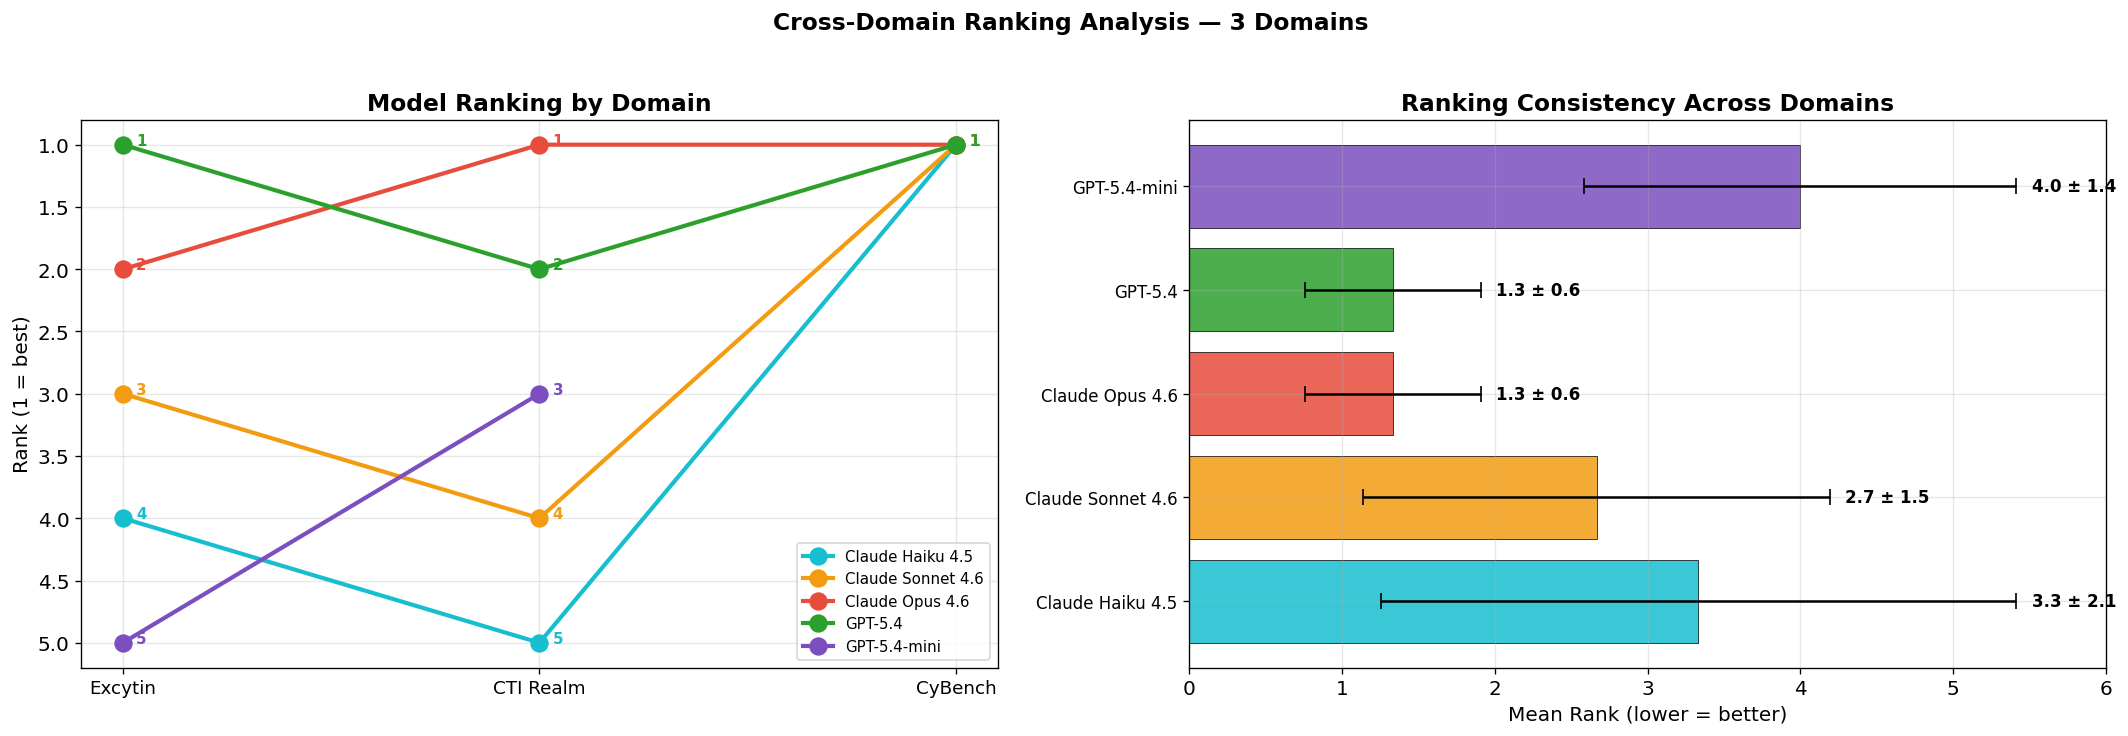

═══ Model Rankings ═══
                   Excytin  CTI Realm  CyBench  Mean Rank  Rank Std
Claude Haiku 4.5       4.0        5.0      1.0       3.33      2.08
Claude Sonnet 4.6      3.0        4.0      1.0       2.67      1.53
Claude Opus 4.6        2.0        1.0      1.0       1.33      0.58
GPT-5.4                1.0        2.0      1.0       1.33      0.58
GPT-5.4-mini           5.0        3.0      NaN       4.00      1.41


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Cross-Domain Ranking Consistency
# ══════════════════════════════════════════════════════════════════════════════

# Rank models within each domain (1=best)
rank_by_domain = pd.DataFrame(index=MODEL_ORDER, columns=domain_slugs, dtype=float)
for slug in domain_slugs:
    col = score_by_domain[slug].dropna()
    ranks = col.rank(ascending=False, method='min')
    for m in ranks.index:
        rank_by_domain.loc[m, slug] = ranks[m]

# Compute rank variance per model (lower = more consistent)
rank_by_domain_display = rank_by_domain.copy()
rank_by_domain_display.columns = [domain_names[s] for s in domain_slugs]
rank_by_domain_display['Mean Rank'] = rank_by_domain.mean(axis=1)
rank_by_domain_display['Rank Std'] = rank_by_domain.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: Bump chart — model ranks across domains
ax = axes[0]
for m in MODEL_ORDER:
    ranks = [rank_by_domain.loc[m, s] for s in domain_slugs if not np.isnan(rank_by_domain.loc[m, s])]
    valid_domains = [domain_names[s] for s in domain_slugs if not np.isnan(rank_by_domain.loc[m, s])]
    if len(ranks) > 0:
        ax.plot(range(len(ranks)), ranks, marker='o', markersize=10,
                linewidth=2.5, color=COLORS.get(m, '#888'), label=m, zorder=5)
        for xi, (r, dn) in enumerate(zip(ranks, valid_domains)):
            ax.annotate(f'{int(r)}', (xi, r), textcoords='offset points',
                       xytext=(8, 0), fontsize=9, fontweight='bold',
                       color=COLORS.get(m, '#888'))

ax.set_xticks(range(len(domain_slugs)))
ax.set_xticklabels([domain_names[s] for s in domain_slugs], fontsize=11)
ax.set_ylabel('Rank (1 = best)')
ax.set_title('Model Ranking by Domain', fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=9, loc='best')

# Panel 2: Rank consistency — mean rank ± std
ax = axes[1]
mean_ranks = [rank_by_domain_display.loc[m, 'Mean Rank'] for m in MODEL_ORDER]
rank_stds = [rank_by_domain_display.loc[m, 'Rank Std'] if not np.isnan(rank_by_domain_display.loc[m, 'Rank Std']) else 0
             for m in MODEL_ORDER]
x = np.arange(len(MODEL_ORDER))
ax.barh(x, mean_ranks, xerr=rank_stds, color=[COLORS.get(m, '#888') for m in MODEL_ORDER],
        edgecolor='black', linewidth=0.5, alpha=0.85, capsize=5)
for i, (mr, rs) in enumerate(zip(mean_ranks, rank_stds)):
    ax.text(mr + rs + 0.1, i, f'{mr:.1f} ± {rs:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_xlabel('Mean Rank (lower = better)')
ax.set_title('Ranking Consistency Across Domains', fontweight='bold')
ax.set_xlim(0, len(MODEL_ORDER) + 1)

fig.suptitle(f'Cross-Domain Ranking Analysis — {len(DOMAINS)} Domains', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'ranking_consistency.png', bbox_inches='tight')
plt.show()

print('═══ Model Rankings ═══')
print(rank_by_domain_display.round(2).to_string())

---

## 8. Cross-Domain Performance Radar

### What this measures

A spider/radar chart showing each model's normalized performance across domains. Scores are plotted on separate axes (one per domain), making it easy to spot models with balanced vs. specialized profiles.

Models with larger radar area perform well across all domains. Asymmetric shapes indicate domain specialization.

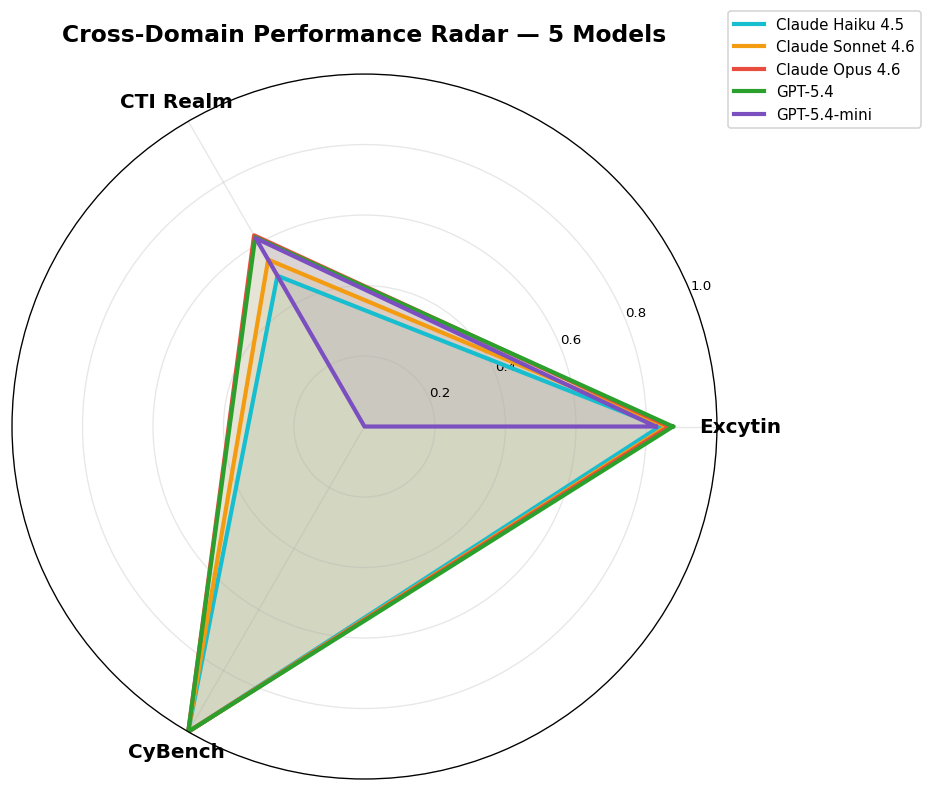

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8: Cross-Domain Radar Chart
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

n_domains = len(domain_slugs)
angles = np.linspace(0, 2 * np.pi, n_domains, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for m in MODEL_ORDER:
    values = [score_by_domain.loc[m, s] if not np.isnan(score_by_domain.loc[m, s]) else 0
              for s in domain_slugs]
    values += values[:1]
    ax.plot(angles, values, linewidth=2.5, label=m, color=COLORS.get(m, '#888'))
    ax.fill(angles, values, alpha=0.1, color=COLORS.get(m, '#888'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels([DOMAINS[s]['name'] for s in domain_slugs], fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title(f'Cross-Domain Performance Radar — {len(MODEL_ORDER)} Models',
             fontweight='bold', pad=20, fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cross_domain_radar.png', bbox_inches='tight')
plt.show()

---

## 9. Extended Reasoning Impact (Domain-Normalized)

### What this measures

Compares the impact of extended reasoning (adaptive thinking / reasoning effort=high) across domains.

For each model that has both reasoning and no-reasoning baselines, computes the per-domain score delta and aggregates with equal weight.

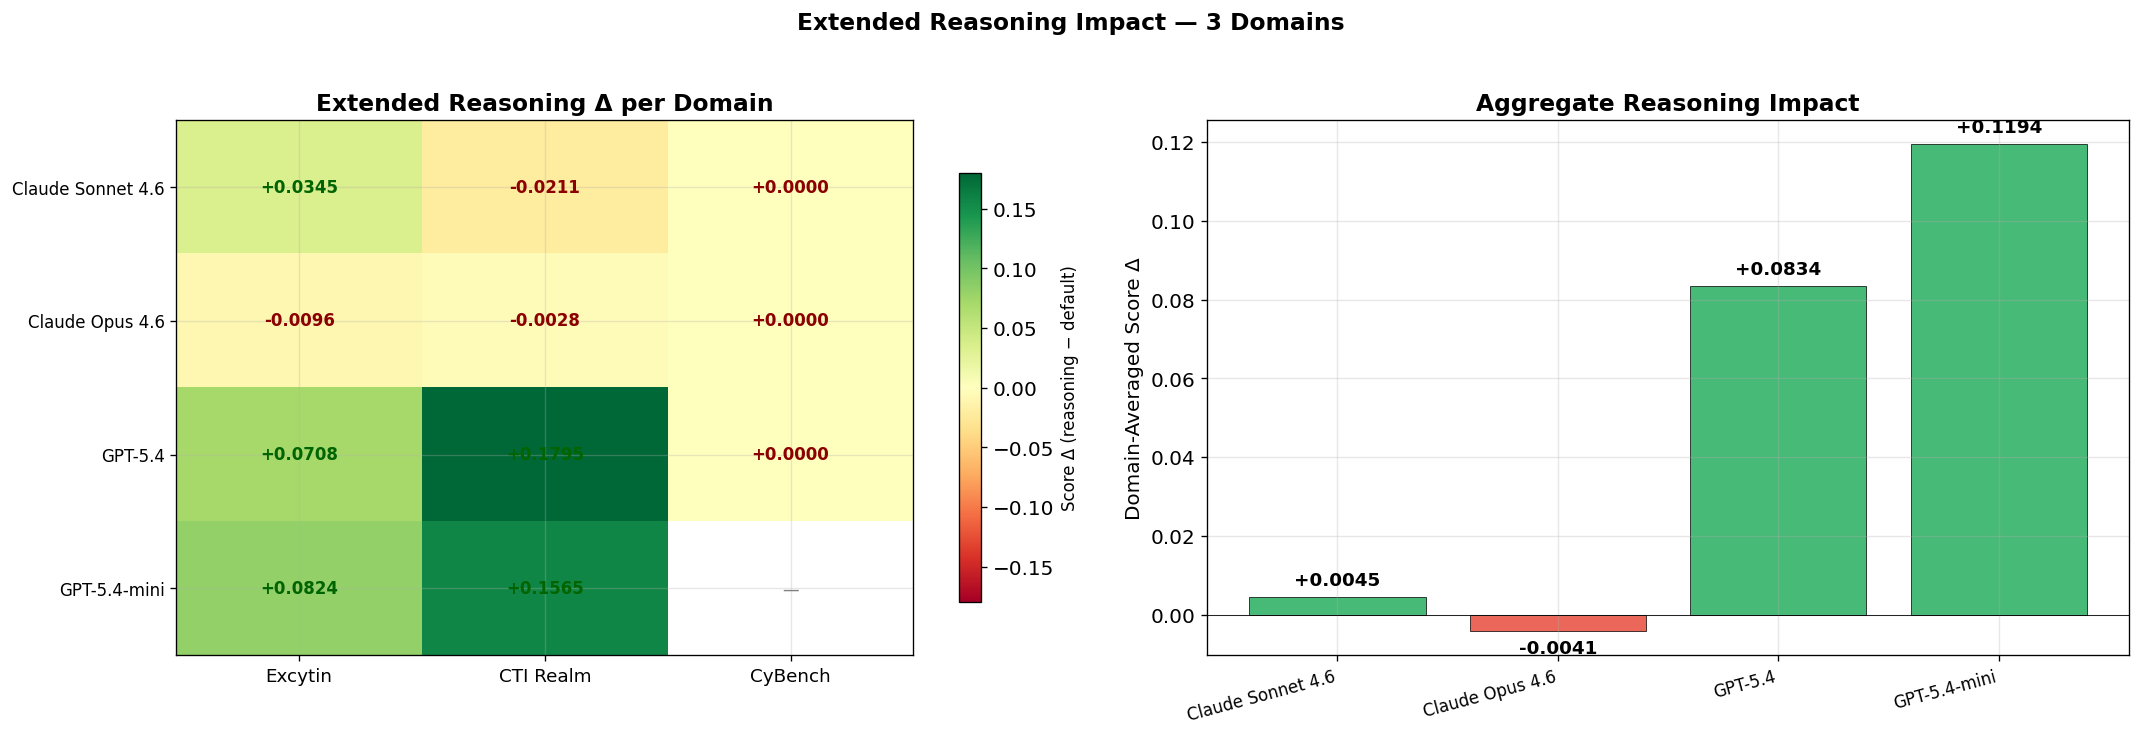

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 9: Extended Reasoning Impact (Domain-Normalized)
# ══════════════════════════════════════════════════════════════════════════════

# Gather per-domain baseline scores
baseline_score_by_domain = pd.DataFrame(index=MODEL_ORDER, columns=domain_slugs, dtype=float)
for slug, dd in domain_data.items():
    for m, stats in dd['no_thinking_overall'].items():
        baseline_score_by_domain.loc[m, slug] = stats['mean']

# Per-domain delta
delta_by_domain = score_by_domain - baseline_score_by_domain

# Models with at least one baseline
models_with_baseline = [m for m in MODEL_ORDER if delta_by_domain.loc[m].notna().any()]

if models_with_baseline:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Panel 1: Per-domain delta heatmap
    ax = axes[0]
    delta_display = delta_by_domain.loc[models_with_baseline].copy()
    delta_display.columns = [domain_names[s] for s in domain_slugs]
    delta_arr = delta_display.values.astype(float)

    vmax = max(0.1, np.nanmax(np.abs(delta_arr)))
    im = ax.imshow(delta_arr, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    for i in range(len(models_with_baseline)):
        for j in range(len(domain_slugs)):
            val = delta_arr[i, j]
            if not np.isnan(val):
                color_t = '#006400' if val > 0 else '#8B0000'
                ax.text(j, i, f'{val:+.4f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color_t)
            else:
                ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='gray')
    ax.set_xticks(range(len(domain_slugs)))
    ax.set_xticklabels(delta_display.columns, fontsize=11)
    ax.set_yticks(range(len(models_with_baseline)))
    ax.set_yticklabels(models_with_baseline, fontsize=10)
    ax.set_title('Extended Reasoning Δ per Domain', fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Score Δ (reasoning − default)', fontsize=10)

    # Panel 2: Aggregate reasoning delta bar chart
    ax = axes[1]
    agg_delta = delta_by_domain.loc[models_with_baseline].mean(axis=1)
    x = np.arange(len(models_with_baseline))
    bar_colors = ['#27AE60' if d > 0 else '#E74C3C' for d in agg_delta]
    ax.bar(x, agg_delta, color=bar_colors, edgecolor='black', linewidth=0.5, alpha=0.85)
    for i, (m, d) in enumerate(zip(models_with_baseline, agg_delta)):
        ax.text(i, d + (0.002 if d > 0 else -0.002), f'{d:+.4f}',
                ha='center', va='bottom' if d > 0 else 'top', fontweight='bold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(models_with_baseline, fontsize=10, rotation=15, ha='right')
    ax.set_ylabel('Domain-Averaged Score Δ')
    ax.set_title('Aggregate Reasoning Impact', fontweight='bold')
    ax.axhline(y=0, color='black', linewidth=0.5)

    fig.suptitle(f'Extended Reasoning Impact — {len(DOMAINS)} Domains',
                 fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'reasoning_impact.png', bbox_inches='tight')
    plt.show()
else:
    print('No baseline (no-reasoning) data available for any model.')

---

## Summary & Next Steps

### Domain-specific analysis

This notebook provides the **aggregate** view. For domain-specific deep dives:
- **Excytin:** [`excytin_analysis.ipynb`](excytin_analysis.ipynb) — per-incident gap heatmap, SQL query analysis
- **CyBench:** [`cybench_analysis.ipynb`](cybench_analysis.ipynb) — per-challenge checkpoint analysis
- **CTI Realm:** [`cti_realm_analysis.ipynb`](cti_realm_analysis.ipynb) — KQL quality, CTI tool usage, checkpoint correlations

### Adding a new domain

1. Create a domain-specific analysis notebook (e.g., `new_domain_analysis.ipynb`)
2. Place eval files in `eval_samples/new_domain/`
3. Add an entry to `DOMAINS` in this notebook's Configuration cell
4. Re-run the notebook — all charts auto-adapt

### Interpretation notes

- **Aggregate scores weight each domain equally**, regardless of sample count
- Models with partial domain coverage have their aggregate computed over available domains only
- Cost comparisons use per-sample costs (not total), making them comparable across domains with different sample counts